# Customer Segmentation Analysis

## Project Overview

This project focuses on grouping customers based on their purchasing behavior and demographics to target marketing strategies effectively. We'll use various machine learning techniques including K-Means, Hierarchical Clustering, and RFM Analysis to identify distinct customer segments.

## Objectives

1. **Analyze customer purchasing patterns** and demographic characteristics
2. **Identify distinct customer segments** using unsupervised machine learning
3. **Develop targeted marketing strategies** for each segment
4. **Provide actionable insights** for business decision-making

## Methodology

- **Data Analysis**: Exploratory Data Analysis (EDA) and statistical insights
- **Feature Engineering**: Creating meaningful features for clustering
- **Clustering Algorithms**: K-Means, Hierarchical Clustering, DBSCAN
- **RFM Analysis**: Recency, Frequency, Monetary value analysis
- **Visualization**: Interactive dashboards and comprehensive plots


In [32]:
# Suppress warnings first
import warnings
warnings.filterwarnings('ignore')

# Scientific and ML Libraries
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.model_selection import train_test_split

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Data Manipulation
import numpy as np
import pandas as pd
import random
from datetime import datetime, timedelta
from collections import Counter

# Display and Plot Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Data Loading and Preprocessing

We'll use the Mall_Customers.csv dataset which contains customer information including:

- **CustomerID**: Unique identifier for each customer
- **Gender**: Customer's gender
- **Age**: Customer's age
- **Annual Income (k$)**: Customer's annual income in thousands
- **Spending Score (1-100)**: Score assigned based on customer behavior and spending nature


In [33]:
# Setting random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Loading the Mall Customers dataset
df = pd.read_csv('Mall_Customers.csv')

# Displaying basic information about the dataset
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Dataset shape: (200, 5)

Column names: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [34]:
# Dataset Overview
print("=== DATASET OVERVIEW ===")
print(f"Total Customers: {len(df):,}")
print(f"Features: {len(df.columns)}")
print(f"Missing Values: {df.isnull().sum().sum()}")

print("\n=== BASIC STATISTICS ===")
print(df.describe())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== CATEGORICAL FEATURES DISTRIBUTION ===")
categorical_cols = ['Gender']
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

=== DATASET OVERVIEW ===
Total Customers: 200
Features: 5
Missing Values: 0

=== BASIC STATISTICS ===
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000

=== DATA TYPES ===
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

=== CATEGORICAL FEATURES DISTRIB

In [35]:
# Data preprocessing and cleaning
# Renaming columns for better readability
df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

print("=== DATASET OVERVIEW AFTER PREPROCESSING ===")
print(f"Total Customers: {len(df):,}")
print(f"Features: {len(df.columns)}")
print(f"Missing Values: {df.isnull().sum().sum()}")

print("\n=== UPDATED COLUMN NAMES ===")
print(list(df.columns))

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== CATEGORICAL FEATURES DISTRIBUTION ===")
print("\nGender Distribution:")
print(df['Gender'].value_counts())

print("\n=== NUMERICAL FEATURES SUMMARY ===")
numerical_cols = ['Age', 'Annual_Income', 'Spending_Score']
print(df[numerical_cols].describe())

=== DATASET OVERVIEW AFTER PREPROCESSING ===
Total Customers: 200
Features: 5
Missing Values: 0

=== UPDATED COLUMN NAMES ===
['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

=== DATA TYPES ===
CustomerID         int64
Gender            object
Age                int64
Annual_Income      int64
Spending_Score     int64
dtype: object

=== CATEGORICAL FEATURES DISTRIBUTION ===

Gender Distribution:
Gender
Female    112
Male       88
Name: count, dtype: int64

=== NUMERICAL FEATURES SUMMARY ===
              Age  Annual_Income  Spending_Score
count  200.000000     200.000000      200.000000
mean    38.850000      60.560000       50.200000
std     13.969007      26.264721       25.823522
min     18.000000      15.000000        1.000000
25%     28.750000      41.500000       34.750000
50%     36.000000      61.500000       50.000000
75%     49.000000      78.000000       73.000000
max     70.000000     137.000000       99.000000


## 2. Exploratory Data Analysis (EDA)

### Understanding Customer Demographics and Behavior Patterns


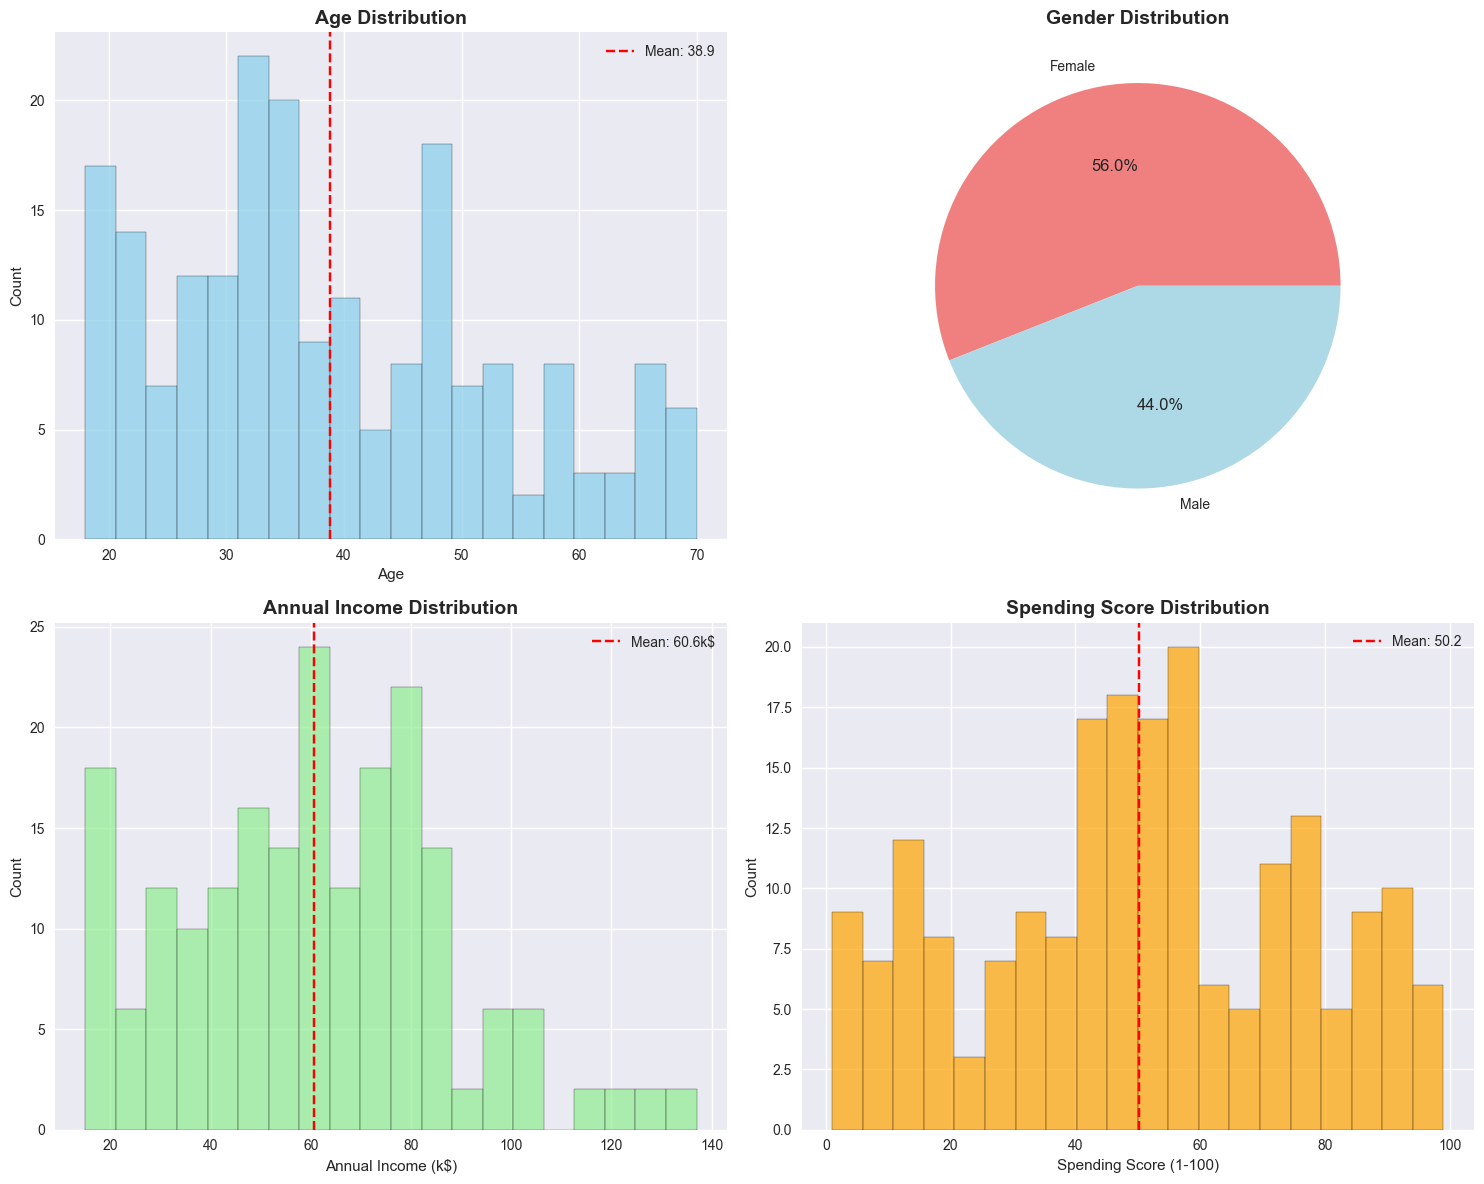

In [36]:
# Demographics Analysis for Mall Customers
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

##############################################################
# Age Distribution
##############################################################
axes[0, 0].hist(
    df['Age'],
    bins=20,
    color='skyblue',
    alpha=0.7,
    edgecolor='black'
)

axes[0, 0].set_title(
    'Age Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')

axes[0, 0].axvline(
    df['Age'].mean(),
    color='red',
    linestyle='--',
    label=f'Mean: {df["Age"].mean():.1f}'
)

axes[0, 0].legend()


##############################################################
# Gender Distribution
##############################################################
gender_counts = df['Gender'].value_counts()

axes[0, 1].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=['lightcoral', 'lightblue']
)

axes[0, 1].set_title(
    'Gender Distribution',
    fontsize=14,
    fontweight='bold'
)


##############################################################
# Annual Income Distribution
##############################################################
axes[1, 0].hist(
    df['Annual_Income'],
    bins=20,
    color='lightgreen',
    alpha=0.7,
    edgecolor='black'
)

axes[1, 0].set_title(
    'Annual Income Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[1, 0].set_xlabel('Annual Income (k$)')
axes[1, 0].set_ylabel('Count')

axes[1, 0].axvline(
    df['Annual_Income'].mean(),
    color='red',
    linestyle='--',
    label=f'Mean: {df["Annual_Income"].mean():.1f}k$'
)

axes[1, 0].legend()


##############################################################
# Spending Score Distribution
##############################################################
axes[1, 1].hist(
    df['Spending_Score'],
    bins=20,
    color='orange',
    alpha=0.7,
    edgecolor='black'
)

axes[1, 1].set_title(
    'Spending Score Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[1, 1].set_xlabel('Spending Score (1-100)')
axes[1, 1].set_ylabel('Count')

axes[1, 1].axvline(
    df['Spending_Score'].mean(),
    color='red',
    linestyle='--',
    label=f'Mean: {df["Spending_Score"].mean():.1f}'
)

axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 2.1 Demographic Analysis


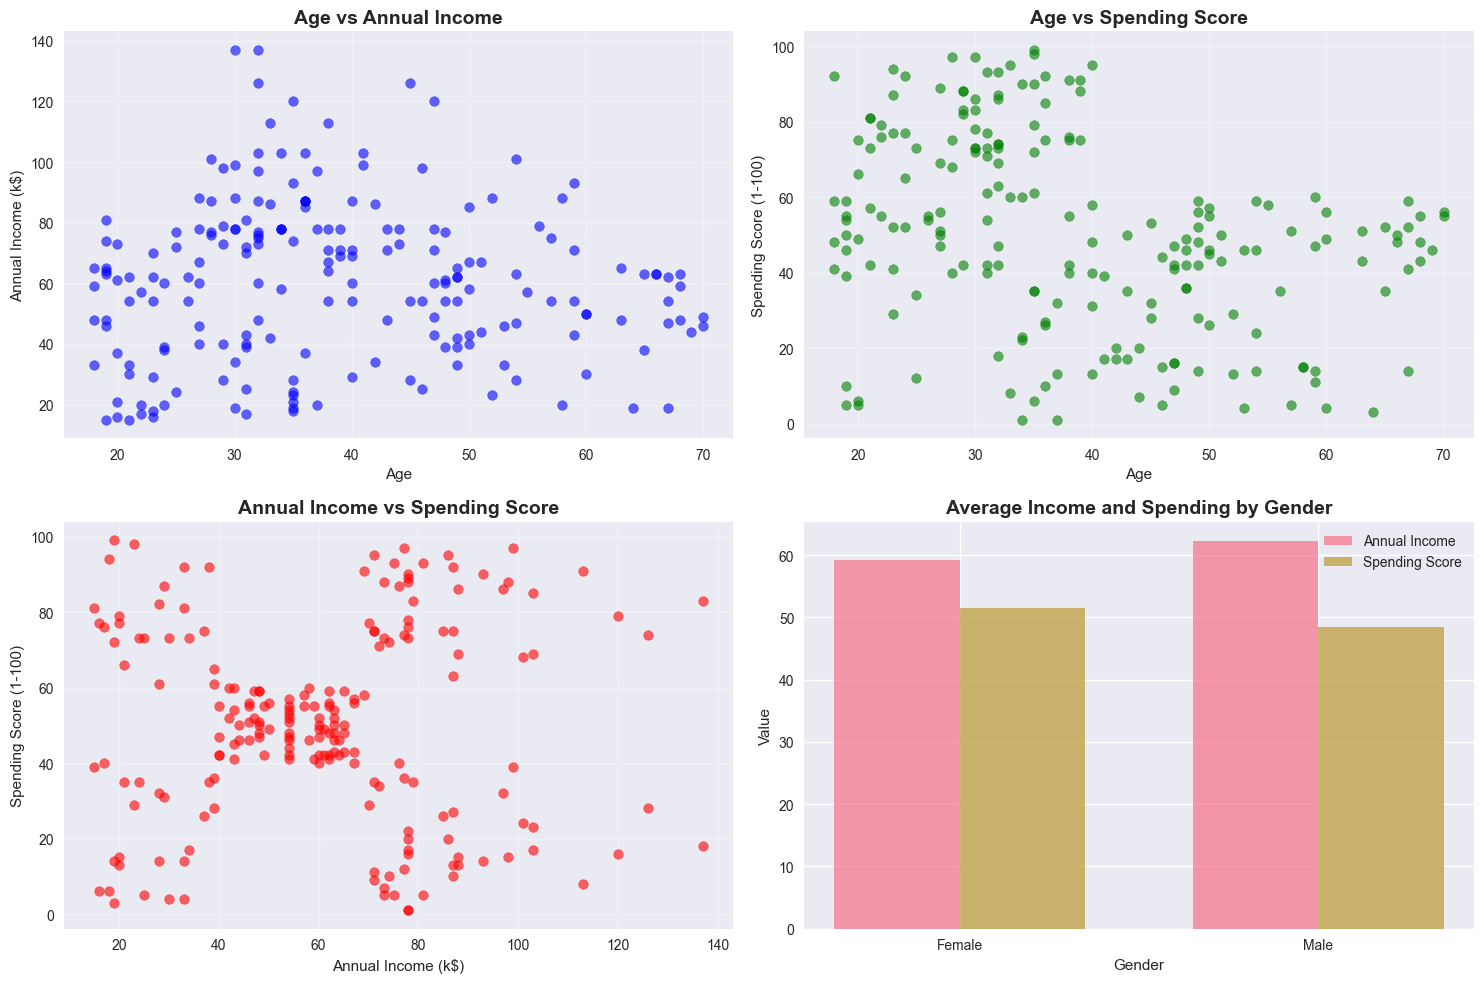

In [37]:
# Customer Behavior Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

##############################################################
# Age vs Annual Income
##############################################################
axes[0, 0].scatter(
    df['Age'],
    df['Annual_Income'],
    alpha=0.6,
    color='blue'
)

axes[0, 0].set_title(
    'Age vs Annual Income',
    fontsize=14,
    fontweight='bold'
)

axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Annual Income (k$)')

axes[0, 0].grid(
    True,
    alpha=0.3
)


##############################################################
# Age vs Spending Score
##############################################################
axes[0, 1].scatter(
    df['Age'],
    df['Spending_Score'],
    alpha=0.6,
    color='green'
)

axes[0, 1].set_title(
    'Age vs Spending Score',
    fontsize=14,
    fontweight='bold'
)

axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Spending Score (1-100)')

axes[0, 1].grid(
    True,
    alpha=0.3
)


##############################################################
# Annual Income vs Spending Score
##############################################################
axes[1, 0].scatter(
    df['Annual_Income'],
    df['Spending_Score'],
    alpha=0.6,
    color='red'
)

axes[1, 0].set_title(
    'Annual Income vs Spending Score',
    fontsize=14,
    fontweight='bold'
)

axes[1, 0].set_xlabel('Annual Income (k$)')
axes[1, 0].set_ylabel('Spending Score (1-100)')

axes[1, 0].grid(
    True,
    alpha=0.3
)


##############################################################
# Gender-based Income and Spending
##############################################################
gender_stats = df.groupby('Gender')[
    ['Annual_Income', 'Spending_Score']
].mean()

x_pos = np.arange(len(gender_stats))
width = 0.35

axes[1, 1].bar(
    x_pos - width/2,
    gender_stats['Annual_Income'],
    width,
    label='Annual Income',
    alpha=0.7
)

axes[1, 1].bar(
    x_pos + width/2,
    gender_stats['Spending_Score'],
    width,
    label='Spending Score',
    alpha=0.7
)

axes[1, 1].set_title(
    'Average Income and Spending by Gender',
    fontsize=14,
    fontweight='bold'
)

axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Value')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(gender_stats.index)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 2.2 Customer Behavior Analysis


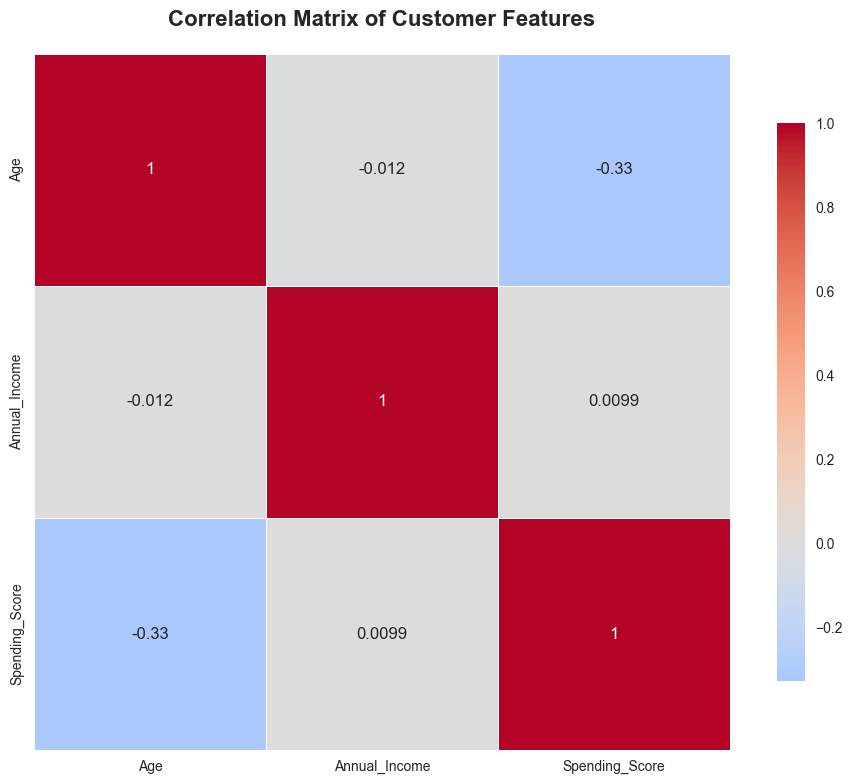

=== KEY CORRELATIONS ===
Age - Spending_Score: -0.327
Age - Annual_Income: -0.012
Annual_Income - Spending_Score: 0.010

=== STATISTICAL SUMMARY BY GENDER ===
          Age                                              Annual_Income  \
        count   mean    std   min    25%   50%   75%   max         count   
Gender                                                                     
Female  112.0  38.10  12.64  18.0  29.00  35.0  47.5  68.0         112.0   
Male     88.0  39.81  15.51  18.0  27.75  37.0  50.5  70.0          88.0   

                                                      Spending_Score         \
         mean    std   min    25%   50%    75%    max          count   mean   
Gender                                                                        
Female  59.25  26.01  16.0  39.75  60.0  77.25  126.0          112.0  51.53   
Male    62.23  26.64  15.0  45.50  62.5  78.00  137.0           88.0  48.51   

                                            
          std  min 

In [39]:
##############################################################
# Correlation Analysis for Mall Customers
##############################################################

numerical_cols = [
    'Age',
    'Annual_Income',
    'Spending_Score'
]


plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()


# Creating heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)


plt.title(
    'Correlation Matrix of Customer Features',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()


##############################################################
# Key correlations
##############################################################

print("=== KEY CORRELATIONS ===")
corr_pairs = []
for i in range(len(numerical_cols)):
    for j in range(i+1, len(numerical_cols)):
        corr_value = correlation_matrix.iloc[i, j]
        corr_pairs.append((numerical_cols[i], numerical_cols[j], corr_value))

corr_pairs.sort(
    key=lambda x: abs(x[2]),
    reverse=True
)

for col1, col2, corr in corr_pairs:
    print(f"{col1} - {col2}: {corr:.3f}")



##############################################################
# Statistical summary by gender
##############################################################
print(f"\n=== STATISTICAL SUMMARY BY GENDER ===")
print(df.groupby('Gender')[numerical_cols].describe().round(2))

### 2.3 Correlation Analysis


## 3. Customer Scoring and Segmentation Analysis

Since the Mall Customers dataset doesn't have traditional RFM data (Recency, Frequency, Monetary), we'll create customer scores based on available features:

- **Age Score**: Categorized age groups
- **Income Score**: Based on annual income levels
- **Spending Score**: Already provided in the dataset (1-100)


In [40]:
# Customer Scoring Implementation for Mall Customers
def calculate_customer_scores(df):
    """Calculates customer scores based on Age, Income, and Spending"""
    
    df_scored = df.copy()

    # Age Score (1-5 scale, where 5 represents the most valuable age group for business)
    # Typically, middle-aged customers (25-35) are considered most valuable
    def age_score(age):
        if 25 <= age <= 35:
            return 5
        elif 18 <= age <= 24 or 36 <= age <= 45:
            return 4
        elif 46 <= age <= 55:
            return 3
        elif 56 <= age <= 65:
            return 2
        else:
            return 1

    df_scored['Age_Score'] = df_scored['Age'].apply(age_score)


    # Income Score (1-5 scale based on quantiles)
    df_scored['Income_Score'] = pd.qcut(
        df_scored['Annual_Income'].rank(method='first'),
        5,
        labels=[1, 2, 3, 4, 5]
    ).astype(int)


    # Spending Score is already provided (1-100), normalize to 1-5 scale
    df_scored['Spending_Score_Normalized'] = pd.cut(
        df_scored['Spending_Score'],
        bins=[0, 20, 40, 60, 80, 100],
        labels=[1, 2, 3, 4, 5]
    ).astype(int)


    # Calculating combined customer value score
    df_scored['Customer_Value_Score'] = (
        df_scored['Age_Score'] + df_scored['Income_Score'] + df_scored['Spending_Score_Normalized']
    ) / 3


    # Creating customer segments based on scores
    def customer_segment(row):
        age_score = row['Age_Score']
        income_score = row['Income_Score']
        spending_score = row['Spending_Score_Normalized']

        if income_score >= 4 and spending_score >= 4:
            return 'High Value'
        elif income_score >= 4 and spending_score <= 2:
            return 'High Income Low Spending'
        elif income_score <= 2 and spending_score >= 4:
            return 'Low Income High Spending'
        elif age_score >= 4 and income_score >= 3 and spending_score >= 3:
            return 'Prime Customers'
        elif spending_score <= 2:
            return 'Low Spending'
        else:
            return 'Standard'

    df_scored['Customer_Segment'] = df_scored.apply(customer_segment, axis=1)

    return df_scored

In [41]:
# Applying customer scoring
df_scored = calculate_customer_scores(df)

print("Customer Scoring completed!")
print(f"\nCustomer Segment Distribution:")
print(df_scored['Customer_Segment'].value_counts())


# Displaying sample of scoring results
print(f"\nSample Customer Scoring Results:")
display_cols = ['CustomerID', 'Age', 'Annual_Income', 'Spending_Score',
                'Age_Score', 'Income_Score', 'Spending_Score_Normalized',
                'Customer_Value_Score', 'Customer_Segment']

print(df_scored[display_cols].head(10))

Customer Scoring completed!

Customer Segment Distribution:
Customer_Segment
Standard                    56
High Income Low Spending    39
High Value                  39
Low Spending                24
Low Income High Spending    23
Prime Customers             19
Name: count, dtype: int64

Sample Customer Scoring Results:
   CustomerID  Age  Annual_Income  Spending_Score  Age_Score  Income_Score  \
0           1   19             15              39          4             1   
1           2   21             15              81          4             1   
2           3   20             16               6          4             1   
3           4   23             16              77          4             1   
4           5   31             17              40          5             1   
5           6   22             17              76          4             1   
6           7   35             18               6          5             1   
7           8   23             18              94    

### 3.1 Customer Scoring Implementation


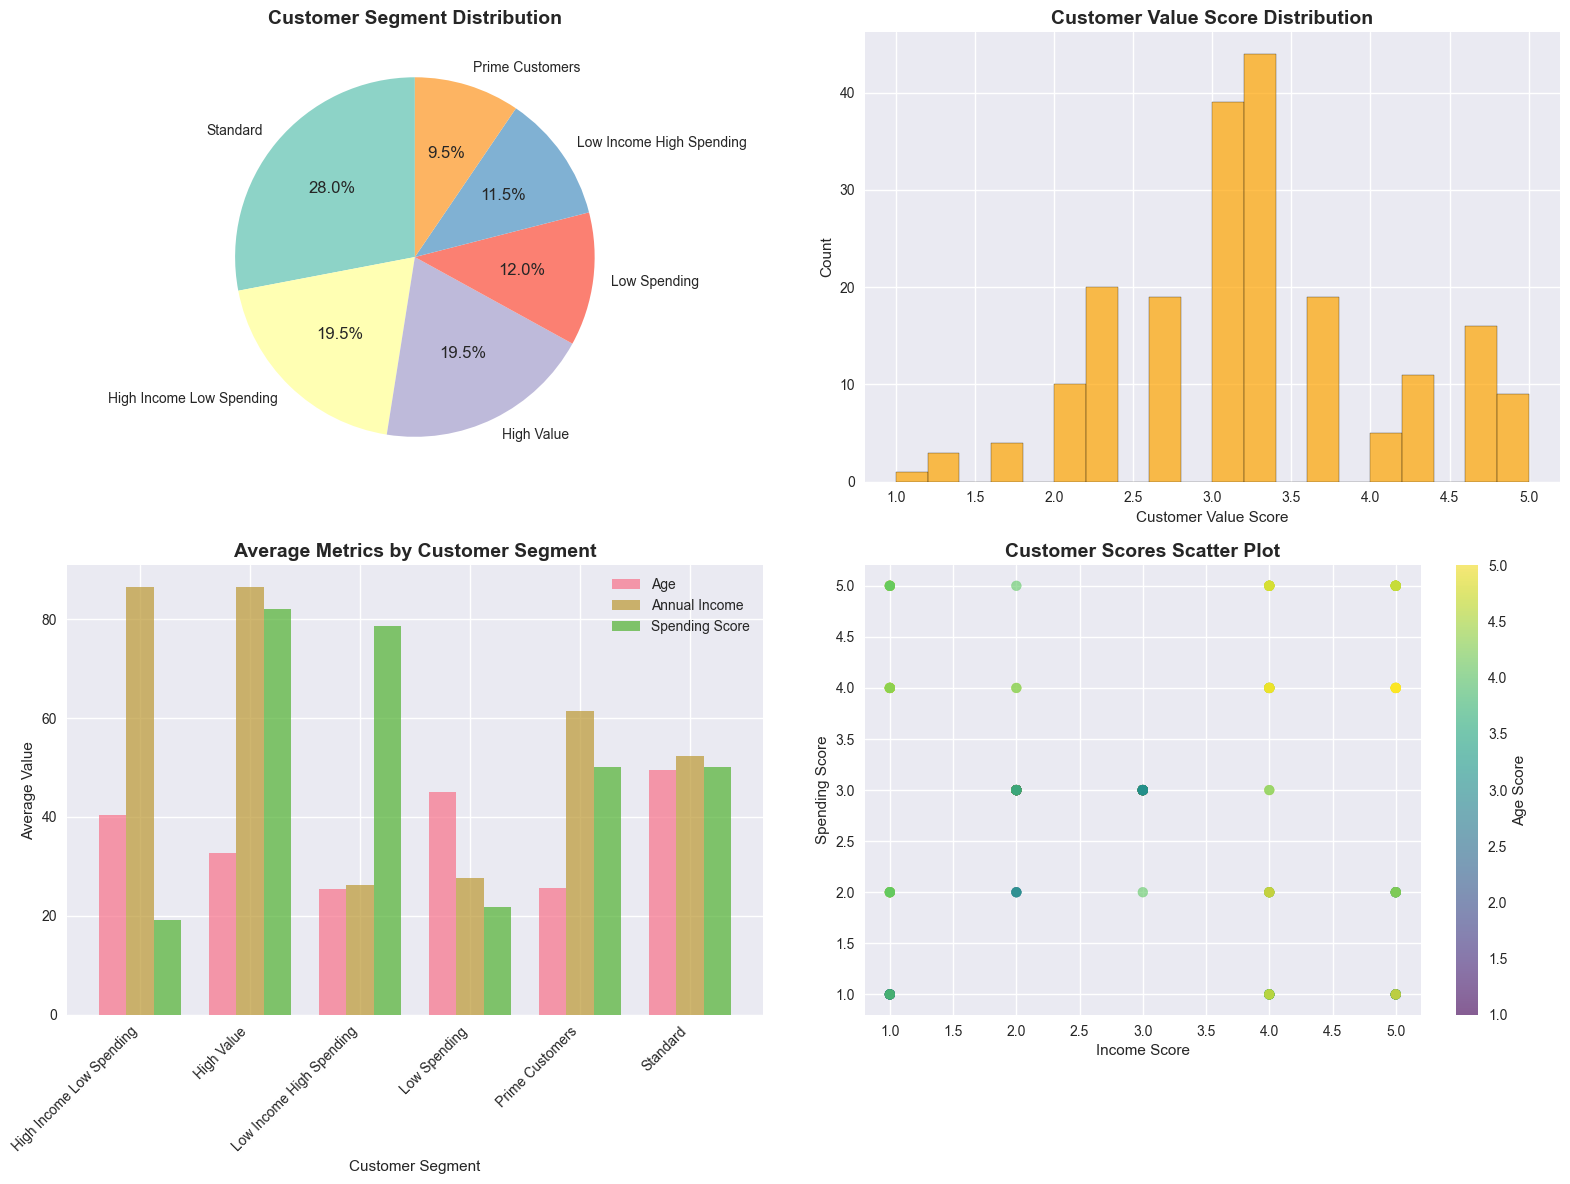

In [42]:
# Customer Scoring Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

##############################################################
# 1. Customer Segment Distribution (Pie Chart)
##############################################################
segment_counts = df_scored['Customer_Segment'].value_counts()

axes[0, 0].pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3.colors
)

axes[0, 0].set_title(
    'Customer Segment Distribution',
    fontsize=14,
    fontweight='bold'
)


##############################################################
# 2. Customer Value Score Distribution (Histogram)
##############################################################
axes[0, 1].hist(
    df_scored['Customer_Value_Score'],
    bins=20,
    color='orange',
    alpha=0.7,
    edgecolor='black'
)

axes[0, 1].set_title(
    'Customer Value Score Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[0, 1].set_xlabel('Customer Value Score')
axes[0, 1].set_ylabel('Count')



##############################################################
# 3. Average Metrics by Segment (Bar Chart)
##############################################################
segment_metrics = df_scored.groupby('Customer_Segment')[['Age', 'Annual_Income', 'Spending_Score']].mean()
x_pos = np.arange(len(segment_metrics))
width = 0.25

axes[1, 0].bar(
    x_pos - width,
    segment_metrics['Age'],
    width,
    label='Age',
    alpha=0.7
)

axes[1, 0].bar(
    x_pos,
    segment_metrics['Annual_Income'],
    width,
    label='Annual Income',
    alpha=0.7
)

axes[1, 0].bar(
    x_pos + width,
    segment_metrics['Spending_Score'],
    width,
    label='Spending Score',
    alpha=0.7
)

axes[1, 0].set_title(
    'Average Metrics by Customer Segment',
    fontsize=14,
    fontweight='bold'
)

axes[1, 0].set_xlabel('Customer Segment')
axes[1, 0].set_ylabel('Average Value')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(segment_metrics.index, rotation=45, ha='right')
axes[1, 0].legend()



##############################################################
# 4. Scatter Plot of Scores
##############################################################
scatter = axes[1, 1].scatter(
    df_scored['Income_Score'],
    df_scored['Spending_Score_Normalized'],
    c=df_scored['Age_Score'],
    s=50,
    alpha=0.6,
    cmap='viridis'
)

axes[1, 1].set_title(
    'Customer Scores Scatter Plot',
    fontsize=14,
    fontweight='bold'
)

axes[1, 1].set_xlabel('Income Score')
axes[1, 1].set_ylabel('Spending Score')
plt.colorbar(scatter, ax=axes[1, 1], label='Age Score')



plt.tight_layout()
plt.show()

### 3.2 Customer Scoring Visualization


## 4. Machine Learning Clustering

We'll apply various clustering algorithms to identify customer segments:

1. **K-Means Clustering** - Partitional clustering
2. **Hierarchical Clustering** - Agglomerative clustering
3. **DBSCAN** - Density-based clustering


In [43]:
# Data Preprocessing for Clustering - Mall Customers
def prepare_clustering_data(df):
    """Prepare Mall Customers data for clustering analysis"""
    df_cluster = df.copy()

    # Selecting numerical features for clustering
    numerical_features = ['Age', 'Annual_Income', 'Spending_Score']

    # Encoding categorical variables
    le_gender = LabelEncoder()
    df_cluster['Gender_Encoded'] = le_gender.fit_transform(df_cluster['Gender'])

    # Features for clustering (numerical + encoded categorical)
    clustering_features = numerical_features + ['Gender_Encoded']

    # Extracting features
    X = df_cluster[clustering_features]

    # Scaling the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X, X_scaled, clustering_features, scaler


##############################################################
# Preparing data for clustering
##############################################################
X, X_scaled, feature_names, scaler = prepare_clustering_data(df_scored)

print("Data preprocessing completed!")
print(f"Features for clustering: {feature_names}")
print(f"Data shape: {X_scaled.shape}")
print(f"Features scaled: Mean={X_scaled.mean():.4f}, Std={X_scaled.std():.4f}")
print("\nOriginal feature ranges:")
for i, feature in enumerate(feature_names):
    print(f"{feature}: {X.iloc[:, i].min():.2f} to {X.iloc[:, i].max():.2f}")


Data preprocessing completed!
Features for clustering: ['Age', 'Annual_Income', 'Spending_Score', 'Gender_Encoded']
Data shape: (200, 4)
Features scaled: Mean=-0.0000, Std=1.0000

Original feature ranges:
Age: 18.00 to 70.00
Annual_Income: 15.00 to 137.00
Spending_Score: 1.00 to 99.00
Gender_Encoded: 0.00 to 1.00


### 4.1 Data Preprocessing for Clustering


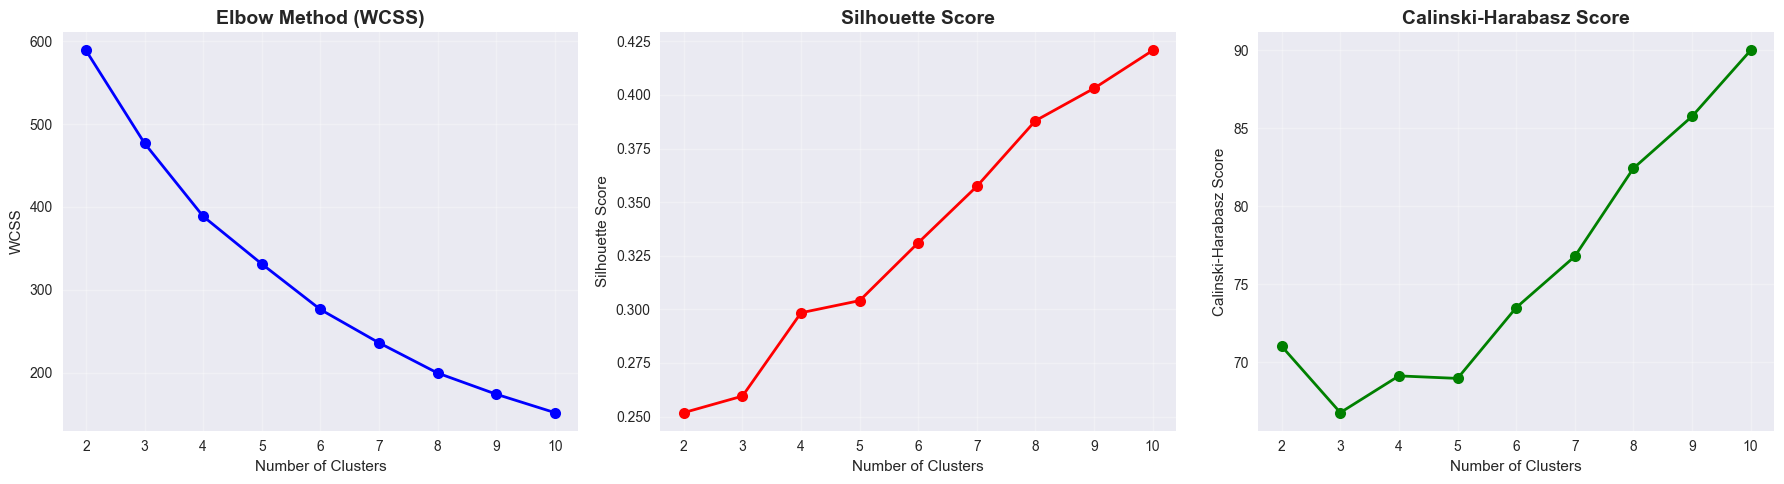

Optimal number of clusters (Silhouette): 10
Optimal number of clusters (Calinski-Harabasz): 10
Silhouette scores: {2: '0.252', 3: '0.260', 4: '0.298', 5: '0.304', 6: '0.331', 7: '0.357', 8: '0.388', 9: '0.403', 10: '0.421'}

Using 10 clusters for further analysis.


In [44]:
# Determining Optimal Number of Clusters
def find_optimal_clusters(X_scaled, max_k=10):
    """Find optimal number of clusters using multiple methods"""
    
    wcss = []
    silhouette_scores = []
    calinski_scores = []
    k_range = range(2, max_k + 1)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X_scaled)
        wcss.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))
        calinski_scores.append(calinski_harabasz_score(X_scaled, cluster_labels))
    return k_range, wcss, silhouette_scores, calinski_scores


##############################################################
# Finding optimal clusters
##############################################################
k_range, wcss, silhouette_scores, calinski_scores = find_optimal_clusters(X_scaled)



# Plot cluster evaluation metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow Method
axes[0].plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (WCSS)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('WCSS')
axes[0].grid(True, alpha=0.3)


# Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)


# Calinski-Harabasz Score
axes[2].plot(k_range, calinski_scores, 'go-', linewidth=2, markersize=8)
axes[2].set_title('Calinski-Harabasz Score', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Clusters')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


##############################################################
# Finding optimal k
##############################################################
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
optimal_k_calinski = k_range[np.argmax(calinski_scores)]


print(f"Optimal number of clusters (Silhouette): {optimal_k_silhouette}")
print(f"Optimal number of clusters (Calinski-Harabasz): {optimal_k_calinski}")
print(f"Silhouette scores: {dict(zip(k_range, [f'{s:.3f}' for s in silhouette_scores]))}")


##############################################################
# Using the silhouette score optimal k
##############################################################
optimal_k = optimal_k_silhouette
print(f"\nUsing {optimal_k} clusters for further analysis.")


### 4.2 Optimal Number of Clusters


In [45]:
##############################################################
# K-Means Clustering for Mall Customers
##############################################################
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)


# Adding cluster labels to original dataframe
df_clustered = df_scored.copy()
df_clustered['KMeans_Cluster'] = kmeans_labels


# Calculating cluster statistics
print("=== K-MEANS CLUSTERING RESULTS ===")
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.3f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_score(X_scaled, kmeans_labels):.1f}")


print(f"\nCluster Distribution:")
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
for cluster, count in cluster_counts.items():
    percentage = (count / len(kmeans_labels)) * 100
    print(f"Cluster {cluster}: {count} customers ({percentage:.1f}%)")


# Clustering characteristics for Mall Customers
print(f"\n=== CLUSTER CHARACTERISTICS ===")
cluster_features = ['Age', 'Annual_Income', 'Spending_Score']
cluster_summary = df_clustered.groupby('KMeans_Cluster')[cluster_features].mean()
print(cluster_summary.round(2))


##############################################################
# Additional insights
##############################################################
print(f"\n=== GENDER DISTRIBUTION BY CLUSTER ===")
gender_by_cluster = df_clustered.groupby(['KMeans_Cluster', 'Gender']).size().unstack(fill_value=0)
print(gender_by_cluster)


=== K-MEANS CLUSTERING RESULTS ===
Number of clusters: 10
Silhouette Score: 0.421
Calinski-Harabasz Score: 90.0

Cluster Distribution:
Cluster 0: 26 customers (13.0%)
Cluster 1: 24 customers (12.0%)
Cluster 2: 14 customers (7.0%)
Cluster 3: 21 customers (10.5%)
Cluster 4: 26 customers (13.0%)
Cluster 5: 19 customers (9.5%)
Cluster 6: 25 customers (12.5%)
Cluster 7: 18 customers (9.0%)
Cluster 8: 13 customers (6.5%)
Cluster 9: 14 customers (7.0%)

=== CLUSTER CHARACTERISTICS ===
                  Age  Annual_Income  Spending_Score
KMeans_Cluster                                      
0               58.85          48.69           39.85
1               25.25          41.25           60.92
2               41.21          26.07           20.14
3               32.19          86.05           81.67
4               54.15          54.23           48.96
5               38.47          85.89           14.21
6               27.96          57.36           47.12
7               33.28          87.11    

### 4.3 K-Means Clustering Implementation


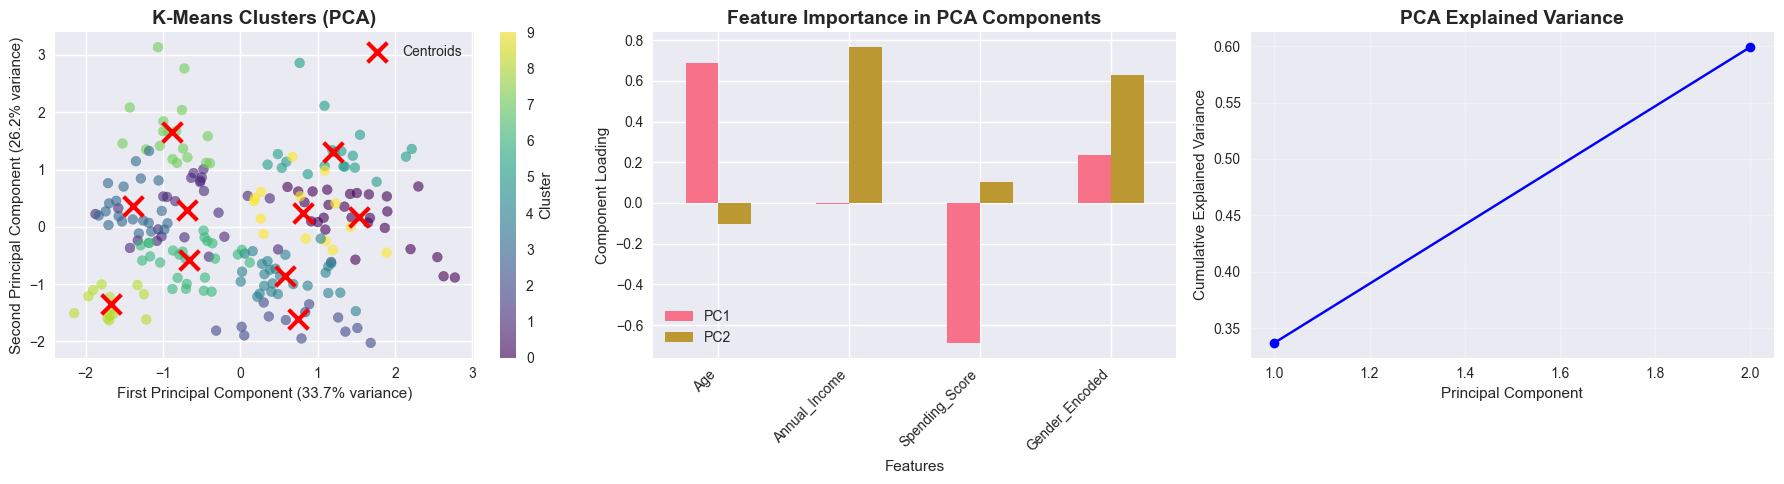

PCA Explained Variance Ratio: [0.33690046 0.26230645]
Total Variance Explained: 59.9%


In [ ]:
##############################################################
# PCA Visualization of Clusters
##############################################################


# Reducing dimensionality for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))



# 1. K-Means clusters in PCA space
scatter = axes[0].scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    c=kmeans_labels,
    cmap='viridis', 
    alpha=0.6, 
    s=50
)

axes[0].set_title(
    'K-Means Clusters (PCA)', 
    fontsize=14, 
    fontweight='bold'
)

axes[0].set_xlabel(
    f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)'
)

axes[0].set_ylabel(
    f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)'
)

plt.colorbar(scatter, ax=axes[0], label='Cluster')



# Plotting cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(
    centers_pca[:, 0], 
    centers_pca[:, 1],
    c='red', 
    marker='x', 
    s=200, 
    linewidths=3, 
    label='Centroids'
)

axes[0].legend()



# 2. Feature importance in PCA
feature_importance = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=feature_names
)

feature_importance.plot(kind='bar', ax=axes[1])
axes[1].set_title('Feature Importance in PCA Components', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Component Loading')
axes[1].set_xticklabels(feature_names, rotation=45, ha='right')



# 3. Explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
axes[2].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
axes[2].set_title('PCA Explained Variance', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Principal Component')
axes[2].set_ylabel('Cumulative Explained Variance')
axes[2].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_):.1%}")

### 4.4 PCA Visualization of Clusters


=== HIERARCHICAL CLUSTERING ===


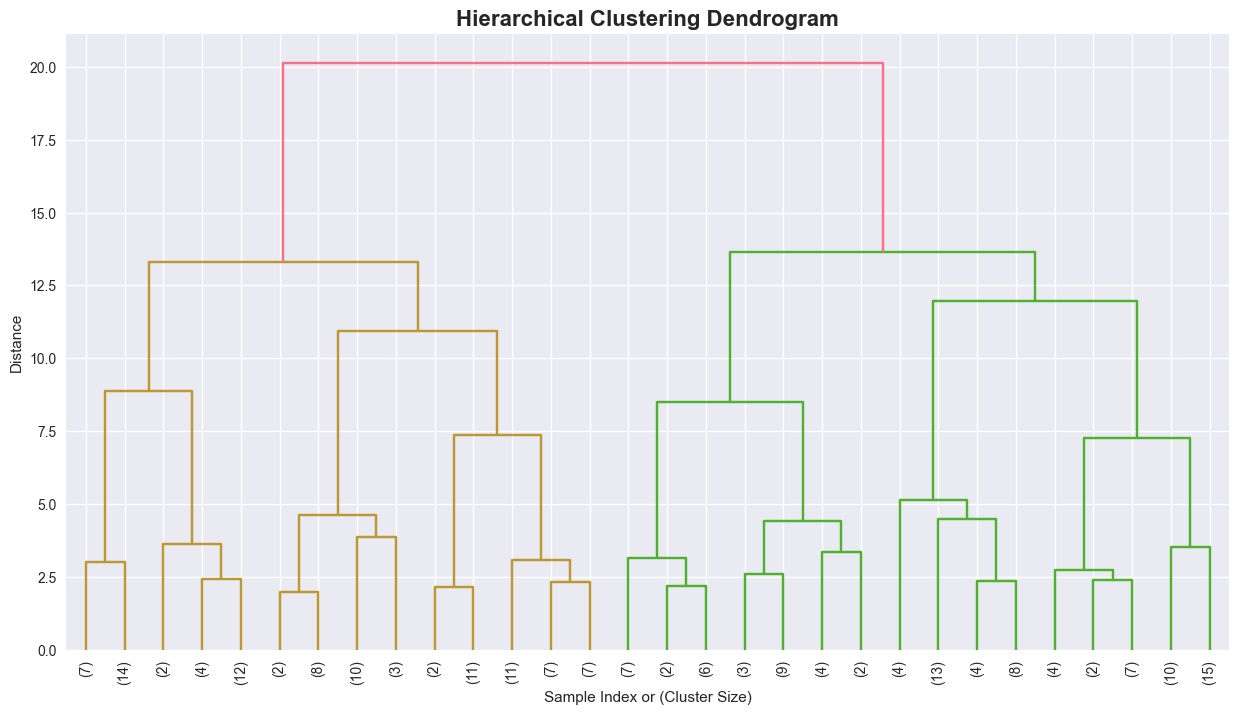

Hierarchical Clustering Silhouette Score: 0.418
Hierarchical Clustering Calinski-Harabasz Score: 87.6

Hierarchical Cluster Distribution:
Cluster 0: 29 customers (14.5%)
Cluster 1: 18 customers (9.0%)
Cluster 2: 23 customers (11.5%)
Cluster 3: 25 customers (12.5%)
Cluster 4: 25 customers (12.5%)
Cluster 5: 18 customers (9.0%)
Cluster 6: 21 customers (10.5%)
Cluster 7: 15 customers (7.5%)
Cluster 8: 13 customers (6.5%)
Cluster 9: 13 customers (6.5%)


In [ ]:
##############################################################
# Hierarchical Clustering
##############################################################
print("=== HIERARCHICAL CLUSTERING ===")

# Creating linkage matrix for dendrogram
linkage_matrix = linkage(
    X_scaled, 
    method='ward'
)

# Plotting dendrogram
plt.figure(figsize=(15, 8))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('Hierarchical Clustering Dendrogram', fontsize=16, fontweight='bold')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.show()


# Applying hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)


# Adding to dataframe
df_clustered['Hierarchical_Cluster'] = hierarchical_labels


# Hierarchical clustering statistics
print(f"Hierarchical Clustering Silhouette Score: {silhouette_score(X_scaled, hierarchical_labels):.3f}")
print(f"Hierarchical Clustering Calinski-Harabasz Score: {calinski_harabasz_score(X_scaled, hierarchical_labels):.1f}")

print("\nHierarchical Cluster Distribution:")
hierarchical_counts = pd.Series(hierarchical_labels).value_counts().sort_index()
for cluster, count in hierarchical_counts.items():
    percentage = (count / len(hierarchical_labels)) * 100
    print(f"Cluster {cluster}: {count} customers ({percentage:.1f}%)")

### 4.5 Hierarchical Clustering


=== DBSCAN CLUSTERING ===


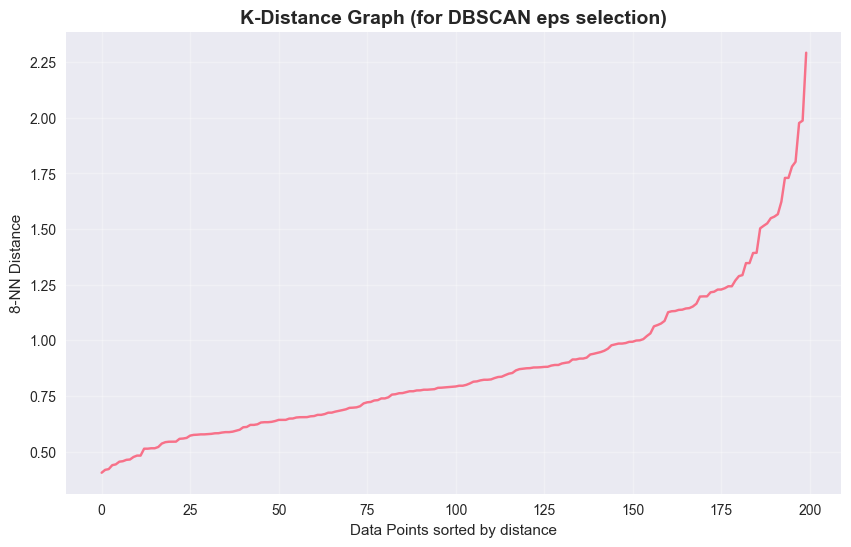

DBSCAN Parameters: eps=1.549, min_samples=8
Number of clusters: 2
Number of noise points: 0
DBSCAN Silhouette Score: 0.278

DBSCAN Cluster Distribution:
Cluster 0: 88 customers (44.0%)
Cluster 1: 112 customers (56.0%)


In [49]:
##############################################################
# DBSCAN Clustering
##############################################################

from sklearn.neighbors import NearestNeighbors

print("=== DBSCAN CLUSTERING ===")

# Finding optimal eps using k-distance graph
# k = minPts = 2 * number of dimensions (rule of thumb)
k = 2 * X_scaled.shape[1]
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sorting distances for k-distance graph
distances = np.sort(distances[:, k - 1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-Distance Graph (for DBSCAN eps selection)', fontsize=14, fontweight='bold')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'{k}-NN Distance')
plt.grid(True, alpha=0.3)
plt.show()

# Selecting eps (95th percentile of distances)
eps = np.percentile(distances, 95)
min_samples = k

print(f"DBSCAN Parameters: eps={eps:.3f}, min_samples={min_samples}")


##############################################################
# Applying DBSCAN
##############################################################
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Adding cluster labels to dataframe
df_clustered['DBSCAN_Cluster'] = dbscan_labels


# DBSCAN statistics
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise}")

if n_clusters_dbscan > 1:
    core_samples = dbscan_labels != -1
    if np.sum(core_samples) > 1:
        score = silhouette_score(X_scaled[core_samples], dbscan_labels[core_samples])
        print(f"DBSCAN Silhouette Score: {score:.3f}")


print("\nDBSCAN Cluster Distribution:")
dbscan_counts = pd.Series(dbscan_labels).value_counts().sort_index()
for cluster, count in dbscan_counts.items():
    percentage = (count / len(dbscan_labels)) * 100
    if cluster == -1:
        print(f"Noise: {count} customers ({percentage:.1f}%)")
    else:
        print(f"Cluster {cluster}: {count} customers ({percentage:.1f}%)")

### 4.6 DBSCAN Clustering


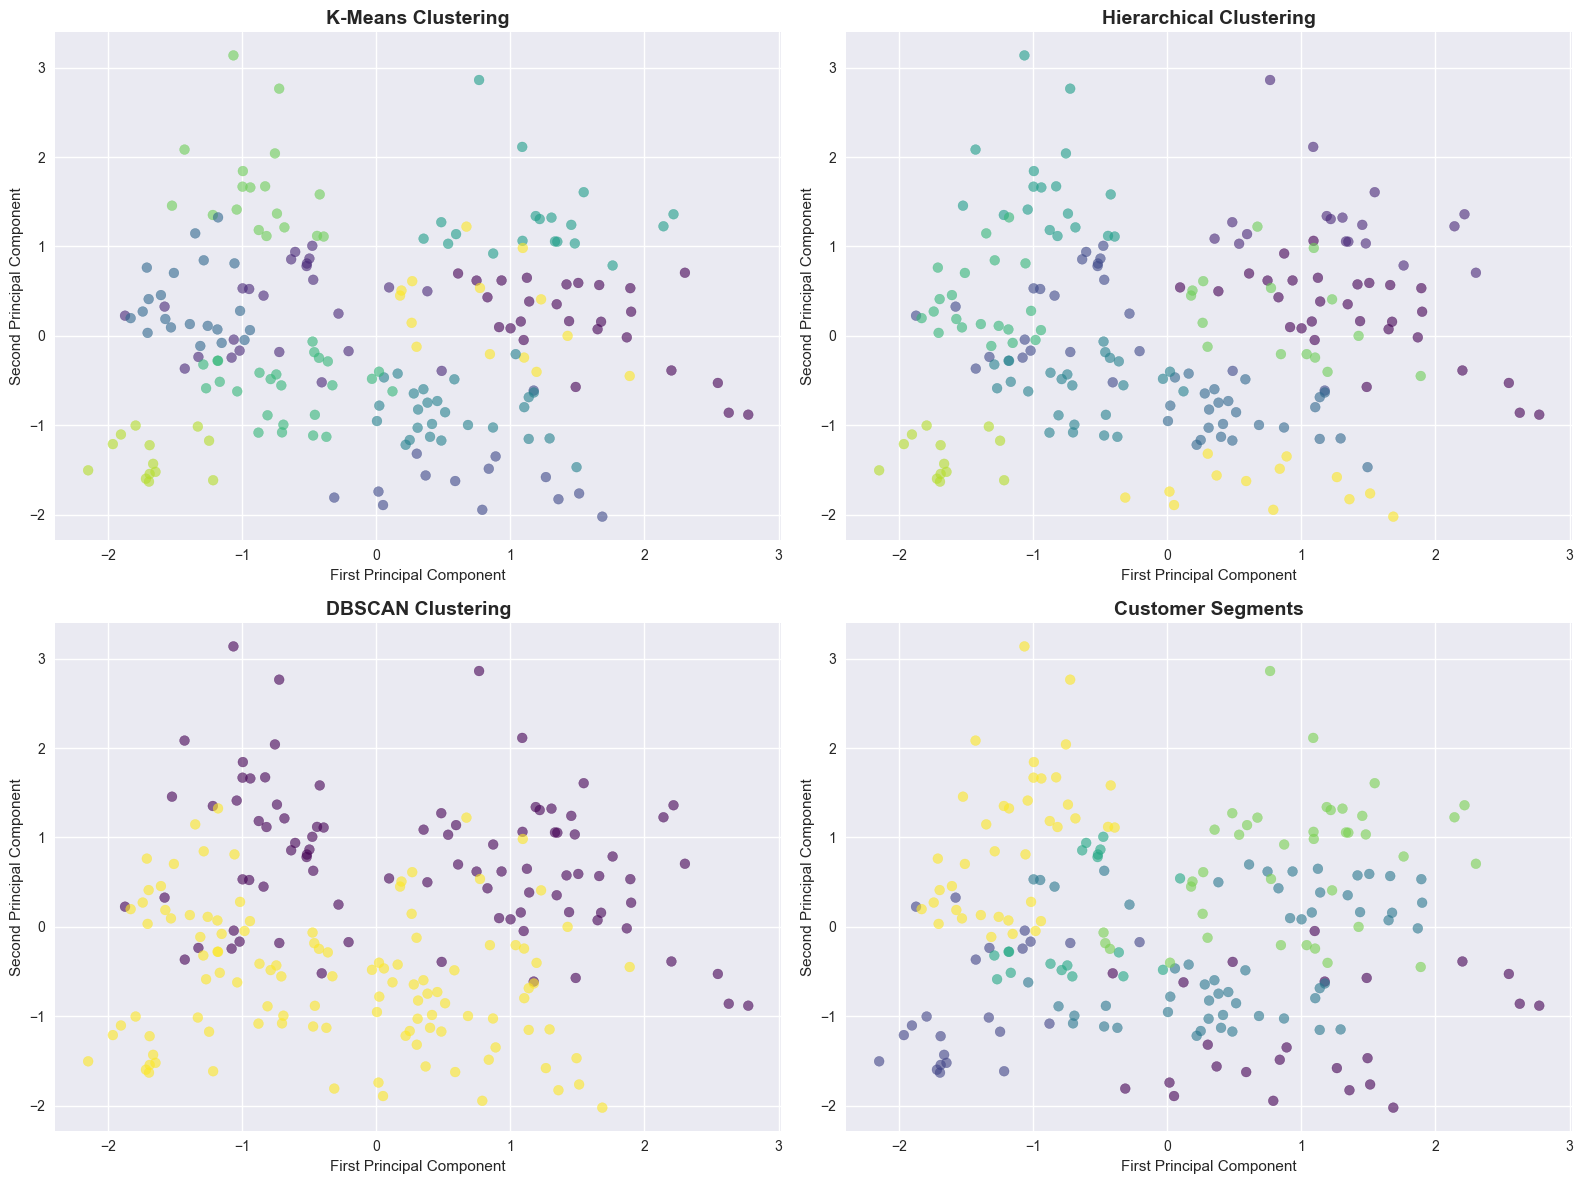

=== CLUSTERING METHOD COMPARISON ===
              Method  Silhouette_Score  Num_Clusters
0             KMeans             0.421            10
1       Hierarchical             0.418            10
2             DBSCAN             0.278             2
3  Customer_Segments             0.197             6


In [50]:
##############################################################
# Comparing Different Clustering Methods for Mall Customers
##############################################################
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


# K-Means Clusters
axes[0, 0].scatter(
    X_pca[:, 0], 
    X_pca[:, 1],
    c=df_clustered['KMeans_Cluster'],
    cmap='viridis', 
    alpha=0.6, 
    s=50
)
axes[0, 0].set_title(
    'K-Means Clustering', 
    fontsize=14, 
    fontweight='bold'
)
axes[0, 0].set_xlabel('First Principal Component')
axes[0, 0].set_ylabel('Second Principal Component')


# Hierarchical Clusters
axes[0, 1].scatter(
    X_pca[:, 0], 
    X_pca[:, 1],
    c=df_clustered['Hierarchical_Cluster'],
    cmap='viridis', 
    alpha=0.6, 
    s=50
)
axes[0, 1].set_title(
    'Hierarchical Clustering', 
    fontsize=14, 
    fontweight='bold'
)
axes[0, 1].set_xlabel('First Principal Component')
axes[0, 1].set_ylabel('Second Principal Component')


# DBSCAN Clusters
scatter = axes[1, 0].scatter(
    X_pca[:, 0], 
    X_pca[:, 1],
    c=df_clustered['DBSCAN_Cluster'],
    cmap='viridis', 
    alpha=0.6, 
    s=50
)
axes[1, 0].set_title(
    'DBSCAN Clustering', 
    fontsize=14, 
    fontweight='bold'
)
axes[1, 0].set_xlabel('First Principal Component')
axes[1, 0].set_ylabel('Second Principal Component')



# Customer Segments (instead of RFM)
segment_map = {segment: i for i, segment in enumerate(df_clustered['Customer_Segment'].unique())}
segment_numeric = df_clustered['Customer_Segment'].map(segment_map)

axes[1, 1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=segment_numeric,
    cmap='viridis', alpha=0.6, s=50
)
axes[1, 1].set_title('Customer Segments', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('First Principal Component')
axes[1, 1].set_ylabel('Second Principal Component')

plt.tight_layout()
plt.show()


##############################################################
# Clustering Method Comparison
##############################################################
print("=== CLUSTERING METHOD COMPARISON ===")
methods = ['KMeans', 'Hierarchical', 'DBSCAN', 'Customer_Segments']

# Calculating silhouette scores for comparison
kmeans_sil = silhouette_score(
    X_scaled, 
    df_clustered['KMeans_Cluster']
)

hierarchical_sil = silhouette_score(
    X_scaled, 
    df_clustered['Hierarchical_Cluster']
)

dbscan_mask = df_clustered['DBSCAN_Cluster'] != -1
if dbscan_mask.sum() > 1 and len(set(df_clustered.loc[dbscan_mask, 'DBSCAN_Cluster'])) > 1:
    dbscan_sil = silhouette_score(
        X_scaled[dbscan_mask], df_clustered.loc[dbscan_mask, 'DBSCAN_Cluster']
    )
else:
    dbscan_sil = -1  # Invalid score

segment_sil = silhouette_score(X_scaled, segment_numeric)

silhouette_scores_comparison = [
    kmeans_sil,
    hierarchical_sil,
    dbscan_sil,
    segment_sil
]

comparison_df = pd.DataFrame({
    'Method': methods,
    'Silhouette_Score': silhouette_scores_comparison,
    'Num_Clusters': [
        len(df_clustered['KMeans_Cluster'].unique()),
        len(df_clustered['Hierarchical_Cluster'].unique()),
        len(df_clustered['DBSCAN_Cluster'].unique()) - (1 if -1 in df_clustered['DBSCAN_Cluster'].values else 0),
        len(df_clustered['Customer_Segment'].unique())
    ]
})

print(comparison_df.round(3))

### 4.7 Clustering Methods Comparison


## 5. Detailed Cluster Profiles and Business Insights

Let's analyze the characteristics of each customer segment to develop targeted marketing strategies.


In [51]:
# Using K-Means clusters for detailed analysis (typically performs well)
cluster_col = 'KMeans_Cluster'

# Comprehensive cluster profiling for Mall Customers
def create_cluster_profiles_mall(df, cluster_col):
    """Create comprehensive cluster profiles for Mall Customers"""
    
    profiles = {}
    for cluster in sorted(df[cluster_col].unique()):
        cluster_data = df[df[cluster_col] == cluster]
        
        profile = {
            'Size': len(cluster_data),
            'Percentage': f"{(len(cluster_data) / len(df)) * 100:.1f}%",
            
            # Demographics
            'Avg_Age': cluster_data['Age'].mean(),
            'Age_Range': f"{cluster_data['Age'].min()}-{cluster_data['Age'].max()}",
            'Avg_Annual_Income': cluster_data['Annual_Income'].mean(),
            'Income_Range': f"{cluster_data['Annual_Income'].min()}-{cluster_data['Annual_Income'].max()}",
            'Gender_Dist': cluster_data['Gender'].value_counts().to_dict(),
            
            # Spending Behavior
            'Avg_Spending_Score': cluster_data['Spending_Score'].mean(),
            'Spending_Range': f"{cluster_data['Spending_Score'].min()}-{cluster_data['Spending_Score'].max()}",
            'Avg_Customer_Value': cluster_data['Customer_Value_Score'].mean(),
            
            # Customer Segments within cluster
            'Top_Customer_Segments': cluster_data['Customer_Segment'].value_counts().head(3).to_dict()
        }
        
        profiles[f'Cluster_{cluster}'] = profile
        
    return profiles


##############################################################
# Generating cluster profiles
##############################################################
cluster_profiles = create_cluster_profiles_mall(df_clustered, cluster_col)


# Displaying profiles
for cluster_name, profile in cluster_profiles.items():
    print(f"\n{'='*60}")
    print(f"  {cluster_name.upper()}")
    print(f"{'='*60}")
    print(f"Size: {profile['Size']} customers ({profile['Percentage']})")
    print(f"\nDEMOGRAPHICS:")
    print(f"  • Average Age: {profile['Avg_Age']:.1f} years (Range: {profile['Age_Range']})")
    print(f"  • Average Annual Income: {profile['Avg_Annual_Income']:.1f}k$ (Range: {profile['Income_Range']}k$)")
    print(f"  • Gender Distribution: {profile['Gender_Dist']}")
    print(f"\nSPENDING BEHAVIOR:")
    print(f"  • Average Spending Score: {profile['Avg_Spending_Score']:.1f}/100 (Range: {profile['Spending_Range']})")
    print(f"  • Average Customer Value Score: {profile['Avg_Customer_Value']:.2f}/5")
    print(f"\nCUSTOMER SEGMENT DISTRIBUTION:")
    
    for segment, count in profile['Top_Customer_Segments'].items():
        percentage = (count / profile['Size']) * 100
        print(f"  • {segment}: {count} ({percentage:.1f}%)")


##############################################################
# Summary insights
##############################################################
print(f"\n{'='*60}")
print("BUSINESS INSIGHTS SUMMARY")
print(f"{'='*60}")


# Find highest value clusters
cluster_values = df_clustered.groupby(cluster_col)['Customer_Value_Score'].mean().sort_values(ascending=False)
print(f"\nHighest Value Clusters (by Customer Value Score):")
for i, (cluster, value) in enumerate(cluster_values.head(3).items()):
    print(f"{i+1}. Cluster {cluster}: {value:.2f}")


# Find best spending clusters
cluster_spending = df_clustered.groupby(cluster_col)['Spending_Score'].mean().sort_values(ascending=False)
print(f"\nHighest Spending Clusters:")
for i, (cluster, spending) in enumerate(cluster_spending.head(3).items()):
    print(f"{i+1}. Cluster {cluster}: {spending:.1f}")



  CLUSTER_0
Size: 26 customers (13.0%)

DEMOGRAPHICS:
  • Average Age: 58.8 years (Range: 47-70)
  • Average Annual Income: 48.7k$ (Range: 19-71k$)
  • Gender Distribution: {'Male': 26}

SPENDING BEHAVIOR:
  • Average Spending Score: 39.8/100 (Range: 3-60)
  • Average Customer Value Score: 2.31/5

CUSTOMER SEGMENT DISTRIBUTION:
  • Standard: 19 (73.1%)
  • Low Spending: 6 (23.1%)
  • High Income Low Spending: 1 (3.8%)

  CLUSTER_1
Size: 24 customers (12.0%)

DEMOGRAPHICS:
  • Average Age: 25.2 years (Range: 18-40)
  • Average Annual Income: 41.2k$ (Range: 15-67k$)
  • Gender Distribution: {'Male': 24}

SPENDING BEHAVIOR:
  • Average Spending Score: 60.9/100 (Range: 35-92)
  • Average Customer Value Score: 3.25/5

CUSTOMER SEGMENT DISTRIBUTION:
  • Low Income High Spending: 9 (37.5%)
  • Prime Customers: 7 (29.2%)
  • Standard: 6 (25.0%)

  CLUSTER_2
Size: 14 customers (7.0%)

DEMOGRAPHICS:
  • Average Age: 41.2 years (Range: 20-58)
  • Average Annual Income: 26.1k$ (Range: 16-39k$)
  

### 5.1 Comprehensive Cluster Profiling


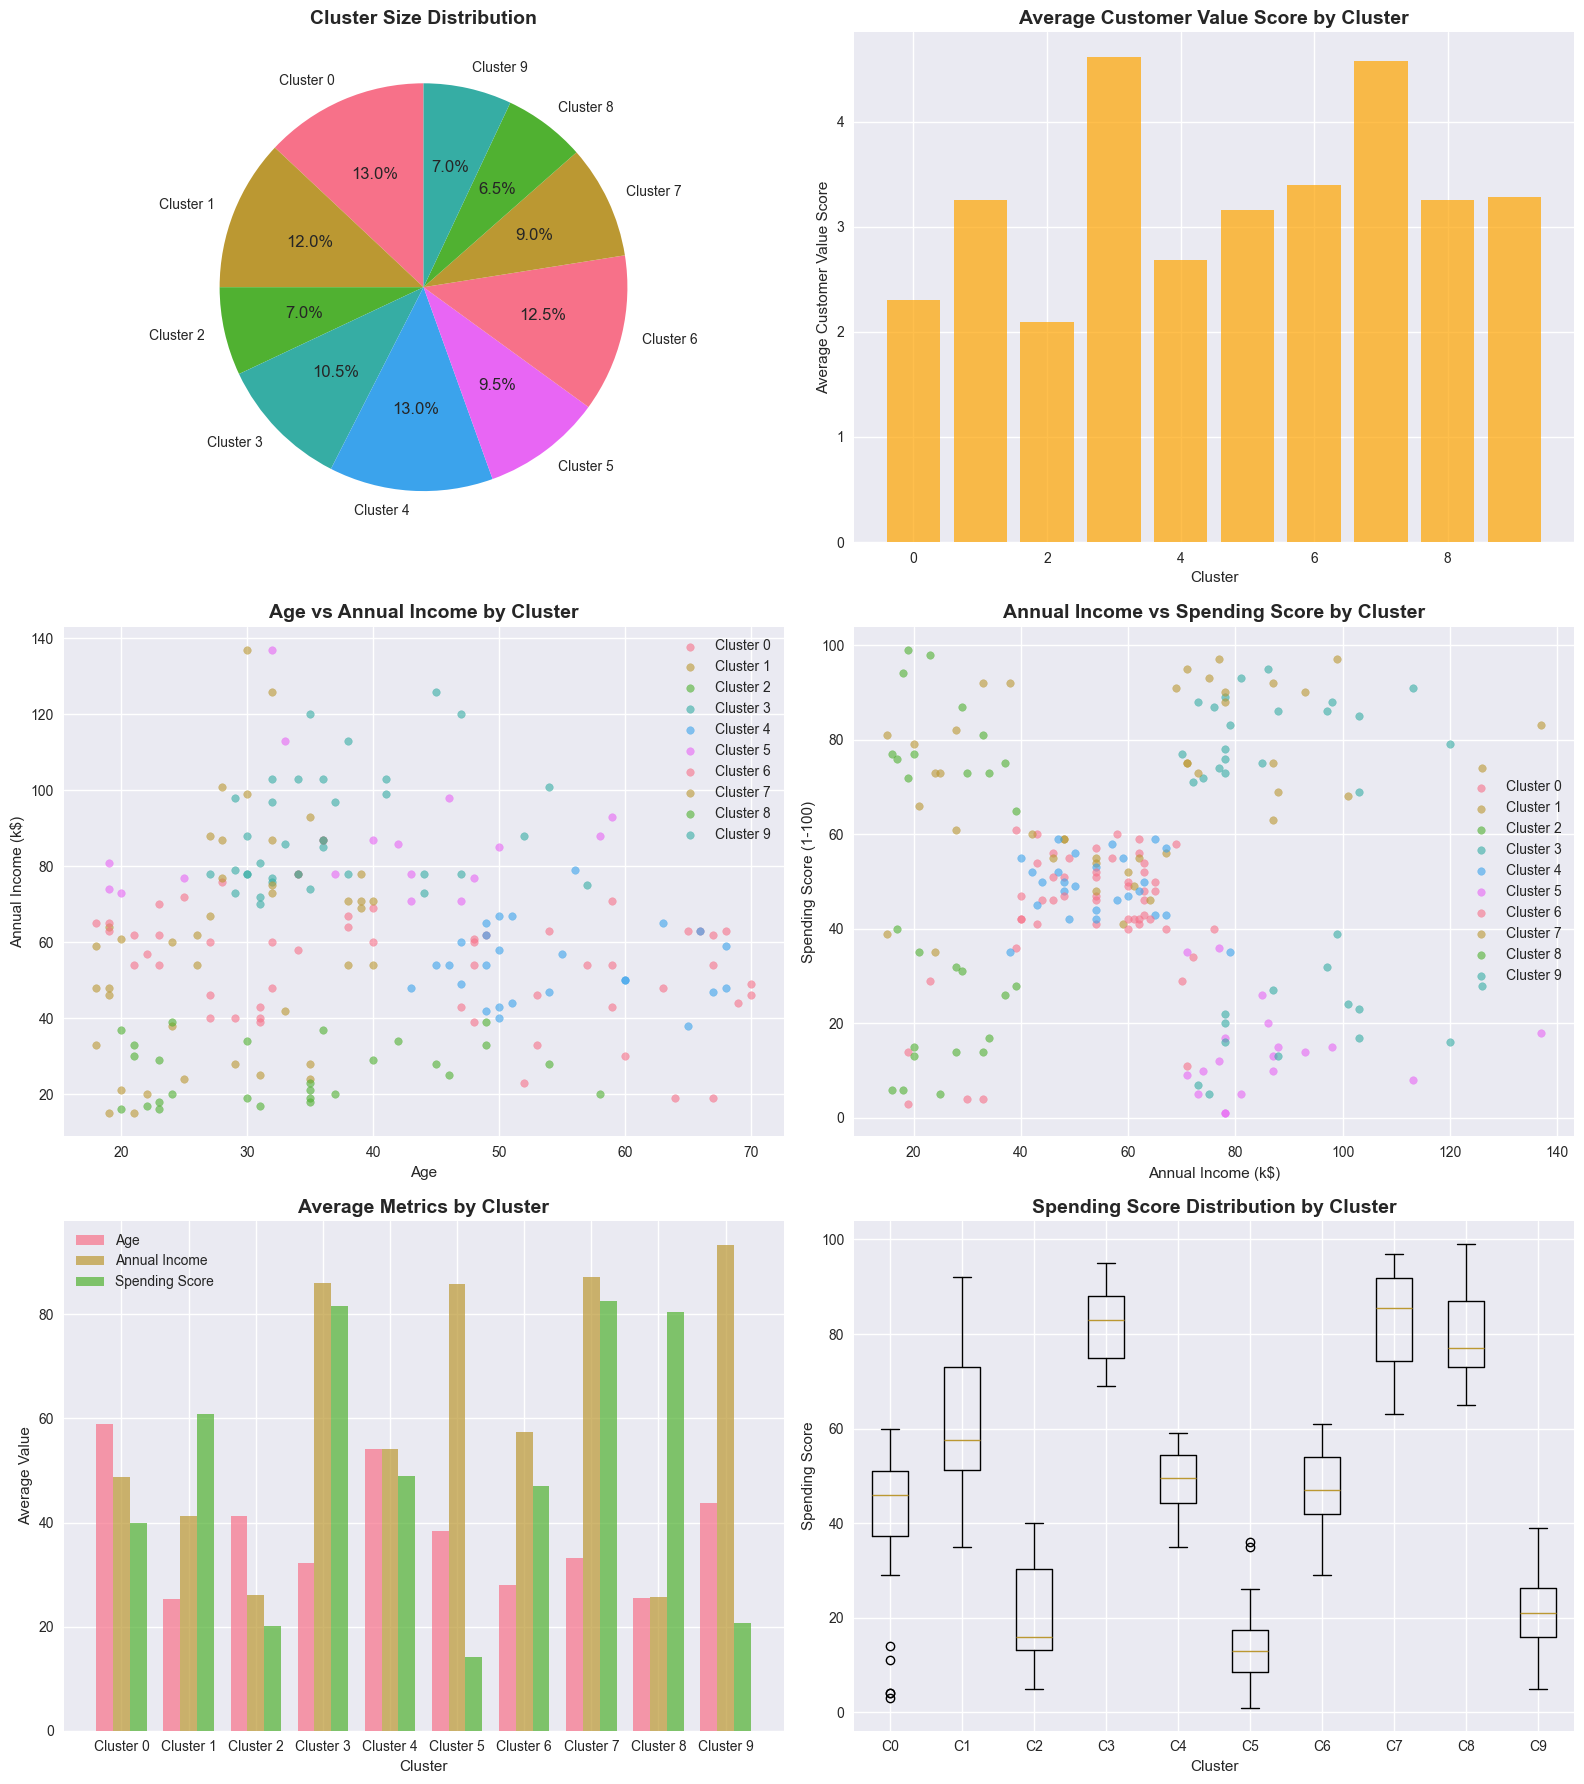

In [52]:
##############################################################
# Cluster Visualization Dashboard for Mall Customers
##############################################################
fig, axes = plt.subplots(3, 2, figsize=(16, 18))


# 1. Cluster Size Distribution
cluster_sizes = df_clustered[cluster_col].value_counts().sort_index()
axes[0, 0].pie(
    cluster_sizes.values,
    labels=[f'Cluster {i}' for i in cluster_sizes.index],
    autopct='%1.1f%%',
    startangle=90
)
axes[0, 0].set_title(
    'Cluster Size Distribution',
    fontsize=14,
    fontweight='bold'
)


# 2. Average Customer Value Score by Cluster
cluster_value = df_clustered.groupby(cluster_col)['Customer_Value_Score'].mean()
axes[0, 1].bar(
    cluster_value.index,
    cluster_value.values,
    color='orange',
    alpha=0.7
)
axes[0, 1].set_title(
    'Average Customer Value Score by Cluster',
    fontsize=14,
    fontweight='bold'
)
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Average Customer Value Score')


# 3. Age vs Annual Income by Cluster
for cluster in sorted(df_clustered[cluster_col].unique()):
    cluster_data = df_clustered[df_clustered[cluster_col] == cluster]
    axes[1, 0].scatter(
        cluster_data['Age'],
        cluster_data['Annual_Income'],
        label=f'Cluster {cluster}',
        alpha=0.6,
        s=30
    )
axes[1, 0].set_title(
    'Age vs Annual Income by Cluster',
    fontsize=14,
    fontweight='bold'
)
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Annual Income (k$)')
axes[1, 0].legend()


# 4. Annual Income vs Spending Score by Cluster
for cluster in sorted(df_clustered[cluster_col].unique()):
    cluster_data = df_clustered[df_clustered[cluster_col] == cluster]
    axes[1, 1].scatter(
        cluster_data['Annual_Income'],
        cluster_data['Spending_Score'],
        label=f'Cluster {cluster}',
        alpha=0.6,
        s=30
    )
axes[1, 1].set_title(
    'Annual Income vs Spending Score by Cluster',
    fontsize=14,
    fontweight='bold'
)
axes[1, 1].set_xlabel('Annual Income (k$)')
axes[1, 1].set_ylabel('Spending Score (1-100)')
axes[1, 1].legend()


# 5. Average Metrics by Cluster
metrics_means = df_clustered.groupby(cluster_col)[['Age', 'Annual_Income', 'Spending_Score']].mean()
x = np.arange(len(metrics_means))
width = 0.25
axes[2, 0].bar(
    x - width,
    metrics_means['Age'],
    width,
    label='Age',
    alpha=0.7
)
axes[2, 0].bar(
    x,
    metrics_means['Annual_Income'],
    width,
    label='Annual Income',
    alpha=0.7
)
axes[2, 0].bar(
    x + width,
    metrics_means['Spending_Score'],
    width,
    label='Spending Score',
    alpha=0.7
)
axes[2, 0].set_title(
    'Average Metrics by Cluster',
    fontsize=14,
    fontweight='bold'
)
axes[2, 0].set_xlabel('Cluster')
axes[2, 0].set_ylabel('Average Value')
axes[2, 0].set_xticks(x)
axes[2, 0].set_xticklabels([f'Cluster {i}' for i in metrics_means.index])
axes[2, 0].legend()


# 6. Spending Score Distribution by Cluster
cluster_spending = [
    df_clustered[df_clustered[cluster_col] == cluster]['Spending_Score'].values
    for cluster in sorted(df_clustered[cluster_col].unique())
]
axes[2, 1].boxplot(
    cluster_spending,
    labels=[f'C{i}' for i in sorted(df_clustered[cluster_col].unique())]
)
axes[2, 1].set_title(
    'Spending Score Distribution by Cluster',
    fontsize=14,
    fontweight='bold'
)
axes[2, 1].set_xlabel('Cluster')
axes[2, 1].set_ylabel('Spending Score')

plt.tight_layout()
plt.show()

## 6. Business Recommendations and Marketing Strategies

Based on our customer segmentation analysis using the Mall Customers dataset, we can develop targeted marketing strategies for each identified customer segment.


In [53]:
##############################################################
# Generating Marketing Recommendations based on Clusters
##############################################################

def generate_marketing_strategies(df, cluster_col):
    """Generate targeted marketing strategies for each cluster"""
    strategies = {}

    for cluster in sorted(df[cluster_col].unique()):
        cluster_data = df[df[cluster_col] == cluster]

        # Calculating cluster characteristics
        avg_age = cluster_data['Age'].mean()
        avg_income = cluster_data['Annual_Income'].mean()
        avg_spending = cluster_data['Spending_Score'].mean()
        gender_dist = cluster_data['Gender'].value_counts()
        dominant_gender = gender_dist.index[0]

        # Generating strategy based on characteristics
        if avg_income >= 70 and avg_spending >= 70:
            segment_name = "High Value Customers"
            strategy = {
                'Segment': segment_name,
                'Characteristics': f"High income ({avg_income:.0f}k$), High spending ({avg_spending:.0f}/100)",
                'Marketing_Strategy': [
                    "Premium product lines and exclusive collections",
                    "VIP membership programs with special privileges",
                    "Personal shopping assistance and consultation",
                    "Limited edition products and early access to sales",
                    "Luxury brand partnerships and collaborations"
                ],
                'Communication_Channels': [
                    "Direct mail", "Email marketing", "Personal calls", "In-store events"
                ],
                'Promotional_Offers': [
                    "Exclusive discounts on premium items",
                    "Loyalty rewards program",
                    "Free premium services"
                ]
            }
        elif avg_income >= 70 and avg_spending <= 40:
            segment_name = "High Income Conservative Spenders"
            strategy = {
                'Segment': segment_name,
                'Characteristics': f"High income ({avg_income:.0f}k$), Low spending ({avg_spending:.0f}/100)",
                'Marketing_Strategy': [
                    "Value-based marketing emphasizing quality and durability",
                    "Educational content about product benefits",
                    "Practical and functional product recommendations",
                    "Money-saving tips and smart shopping guides",
                    "Investment-focused product positioning"
                ],
                'Communication_Channels': [
                    "Email newsletters", "Social media", "Blog content", "Webinars"
                ],
                'Promotional_Offers': [
                    "Bundle deals", "Buy-more-save-more offers", "Cashback programs"
                ]
            }
        elif avg_income <= 40 and avg_spending >= 70:
            segment_name = "Budget-conscious High Spenders"
            strategy = {
                'Segment': segment_name,
                'Characteristics': f"Low income ({avg_income:.0f}k$), High spending ({avg_spending:.0f}/100)",
                'Marketing_Strategy': [
                    "Affordable fashion and trendy items",
                    "Payment plan options and installments",
                    "Budget-friendly alternatives to premium products",
                    "Seasonal sales and flash deals",
                    "Student and young professional discounts"
                ],
                'Communication_Channels': [
                    "Social media", "Mobile apps", "SMS marketing", "Influencer partnerships"
                ],
                'Promotional_Offers': [
                    "Flash sales", "Student discounts", "Payment plans", "Group buying discounts"
                ]
            }
        elif avg_spending <= 40:
            segment_name = "Price-sensitive Customers"
            strategy = {
                'Segment': segment_name,
                'Characteristics': f"Low spending ({avg_spending:.0f}/100), Price-conscious",
                'Marketing_Strategy': [
                    "Budget-friendly product lines and basic essentials",
                    "Clear value propositions and cost comparisons",
                    "Bulk purchase options and family packs",
                    "Generic and store-brand alternatives",
                    "Practical utility-focused messaging"
                ],
                'Communication_Channels': [
                    "Local advertising", "Coupon books", "Email deals", "Word-of-mouth"
                ],
                'Promotional_Offers': [
                    "Deep discounts", "BOGO offers", "Clearance sales", "Price matching"
                ]
            }
        else:
            segment_name = "Balanced Customers"
            strategy = {
                'Segment': segment_name,
                'Characteristics': f"Moderate income ({avg_income:.0f}k$), Moderate spending ({avg_spending:.0f}/100)",
                'Marketing_Strategy': [
                    "Mid-range product offerings with good value",
                    "Seasonal collections and trending items",
                    "Balanced mix of quality and affordability",
                    "Lifestyle-focused marketing approach",
                    "Community engagement and social responsibility"
                ],
                'Communication_Channels': [
                    "Multi-channel approach", "Social media", "Email", "Community events"
                ],
                'Promotional_Offers': [
                    "Seasonal sales", "Member discounts", "Referral programs"
                ]
            }

        # Addding demographic insights
        strategy['Target_Demographics'] = f"Primary: {dominant_gender}, Average age: {avg_age:.0f} years"
        strategy['Cluster_Size'] = f"{len(cluster_data)} customers ({len(cluster_data)/len(df)*100:.1f}%)"
        strategies[f'Cluster_{cluster}'] = strategy

    return strategies


##############################################################
# Generating marketing strategies
##############################################################
marketing_strategies = generate_marketing_strategies(df_clustered, cluster_col)

##############################################################
# Displaying marketing strategies
##############################################################
print("=" * 80)
print("TARGETED MARKETING STRATEGIES FOR MALL CUSTOMERS")
print("=" * 80)


for cluster_name, strategy in marketing_strategies.items():
    print(f"\n{cluster_name.upper()} - {strategy['Segment']}")
    print("-" * 60)
    print(f"Cluster Size: {strategy['Cluster_Size']}")
    print(f"Characteristics: {strategy['Characteristics']}")
    print(f"Target Demographics: {strategy['Target_Demographics']}\n")

    print("Marketing Strategy:")
    for i, point in enumerate(strategy['Marketing_Strategy'], 1):
        print(f"  {i}. {point}")

    print("\nCommunication Channels:")
    print(f"  • {', '.join(strategy['Communication_Channels'])}")

    print("\nPromotional Offers:")
    print(f"  • {', '.join(strategy['Promotional_Offers'])}")
    print()

##############################################################
# Summary and Key Insights
##############################################################
print("=" * 80)
print("KEY BUSINESS INSIGHTS")
print("=" * 80)

total_customers = len(df_clustered)
high_value_customers = len(df_clustered[(df_clustered['Annual_Income'] >= 70) & (df_clustered['Spending_Score'] >= 70)])
potential_customers = len(df_clustered[(df_clustered['Annual_Income'] >= 70) & (df_clustered['Spending_Score'] <= 40)])

print(f"• Total customers analyzed: {total_customers}")
print(f"• High-value customers: {high_value_customers} ({high_value_customers/total_customers*100:.1f}%)")
print(f"• Potential customers (high income, low spending): {potential_customers} ({potential_customers/total_customers*100:.1f}%)")
print(f"• Revenue opportunity: Focus on converting {potential_customers} potential customers")
print(f"• Retention focus: Maintain satisfaction of {high_value_customers} high-value customers")

TARGETED MARKETING STRATEGIES FOR MALL CUSTOMERS

CLUSTER_0 - Price-sensitive Customers
------------------------------------------------------------
Cluster Size: 26 customers (13.0%)
Characteristics: Low spending (40/100), Price-conscious
Target Demographics: Primary: Male, Average age: 59 years

Marketing Strategy:
  1. Budget-friendly product lines and basic essentials
  2. Clear value propositions and cost comparisons
  3. Bulk purchase options and family packs
  4. Generic and store-brand alternatives
  5. Practical utility-focused messaging

Communication Channels:
  • Local advertising, Coupon books, Email deals, Word-of-mouth

Promotional Offers:
  • Deep discounts, BOGO offers, Clearance sales, Price matching


CLUSTER_1 - Balanced Customers
------------------------------------------------------------
Cluster Size: 24 customers (12.0%)
Characteristics: Moderate income (41k$), Moderate spending (61/100)
Target Demographics: Primary: Male, Average age: 25 years

Marketing Strate

## 7. Conclusion and Next Steps

### Summary of Findings

This customer segmentation analysis of the Mall Customers dataset has successfully identified distinct customer groups with unique characteristics and behaviors. Using machine learning clustering techniques (K-Means, Hierarchical, and DBSCAN), we've segmented customers based on age, annual income, spending score, and gender.

### Key Achievements

1. **Data-Driven Segmentation**: Successfully applied multiple clustering algorithms to identify customer segments
2. **Actionable Insights**: Generated specific marketing strategies for each customer segment
3. **Business Value**: Identified high-value customers and potential growth opportunities
4. **Comprehensive Analysis**: Combined demographic analysis, behavioral patterns, and predictive modeling


### Technical Excellence

- **Multiple Algorithms**: Compared K-Means, Hierarchical, and DBSCAN clustering
- **Validation**: Used silhouette scores and other metrics for cluster quality assessment
- **Visualization**: Created comprehensive dashboards for business stakeholders
- **Scalability**: Developed reusable code framework for future analysis

This analysis provides a solid foundation for data-driven marketing decisions and customer relationship management strategies.